# Part 4 – Vector Databases: Embeddings & Cosine Similarity Demo
**Topics covered:** Cricket, Cooking, Cybersecurity  
**Model:** `all-MiniLM-L6-v2` from `sentence-transformers`

In [1]:
# Install required libraries (run once in Colab)
!pip install sentence-transformers seaborn matplotlib -q

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# ── 10 sentences across 3 topics ───────────────────────────────────────────
sentences = [
    # Cricket (indices 0–3)
    "The batsman hit a magnificent six over long-on.",
    "India won the Test match by an innings and 50 runs.",
    "The spinner bowled a perfect googly that deceived the batsman.",
    "Rohit Sharma scored a brilliant century in the ODI series.",
    # Cooking (indices 4–6)
    "Sauté the onions in olive oil until they are golden brown.",
    "The recipe calls for marinating the chicken overnight in yoghurt and spices.",
    "Fold the egg whites gently into the batter to keep the cake fluffy.",
    # Cybersecurity (indices 7–9)
    "The ransomware encrypted all files and demanded a Bitcoin payment.",
    "Always enable two-factor authentication to protect your accounts.",
    "A SQL injection attack can expose the entire customer database.",
]

labels = [
    "Cricket-1", "Cricket-2", "Cricket-3", "Cricket-4",
    "Cooking-1", "Cooking-2", "Cooking-3",
    "Cyber-1",   "Cyber-2",   "Cyber-3",
]

print(f"Total sentences: {len(sentences)}")

Total sentences: 10


In [3]:
# ── Load model and generate embeddings ────────────────────────────────────
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences, convert_to_numpy=True)

print(f"Embedding shape: {embeddings.shape}")
# Expected: (10, 384)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding shape: (10, 384)


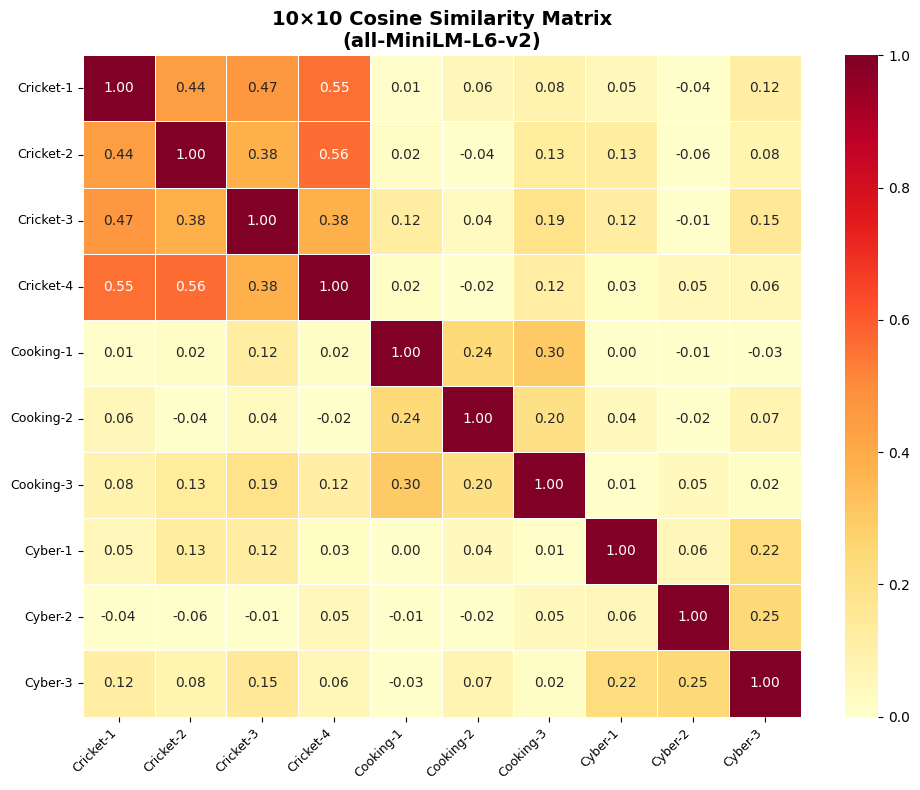

Heatmap saved as similarity_heatmap.png


In [4]:
# ── Compute 10×10 cosine similarity matrix ─────────────────────────────────
sim_matrix = cosine_similarity(embeddings)

plt.figure(figsize=(10, 8))
sns.heatmap(
    sim_matrix,
    xticklabels=labels,
    yticklabels=labels,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    vmin=0, vmax=1,
    linewidths=0.5
)
plt.title('10×10 Cosine Similarity Matrix\n(all-MiniLM-L6-v2)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('similarity_heatmap.png', dpi=150)
plt.show()
print("Heatmap saved as similarity_heatmap.png")

In [5]:
# ── Query: find top-2 most similar sentences ──────────────────────────────
query = "The bowler took three wickets in one over"
query_embedding = model.encode([query], convert_to_numpy=True)

# Compute similarity between query and all 10 sentences
query_similarities = cosine_similarity(query_embedding, embeddings)[0]

# Get top-2 indices (excluding the query itself if it were in the set)
top2_indices = np.argsort(query_similarities)[::-1][:2]

print(f'Query: "{query}"\n')
print('Top 2 most similar sentences:')
for rank, idx in enumerate(top2_indices, 1):
    print(f'  {rank}. [{labels[idx]}] "{sentences[idx]}"')
    print(f'     Similarity score: {query_similarities[idx]:.4f}\n')

Query: "The bowler took three wickets in one over"

Top 2 most similar sentences:
  1. [Cricket-3] "The spinner bowled a perfect googly that deceived the batsman."
     Similarity score: 0.5757

  2. [Cricket-1] "The batsman hit a magnificent six over long-on."
     Similarity score: 0.5549

